# ICS 2207 Scientific Computing | Week 8
## Data Analysis with Pandas - Abusive Language Dataset

Welcome! In this notebook, we'll dive Python's **Pandas** library to perform data analysis. We'll be working with an 'Abusive Language Dataset'. The goal here is to interactively load, inspect, clean, and visualize the data while keeping the original file completely untouched.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a nice plotting style for our graphs
plt.style.use('ggplot')

### 1. What is Pandas? (Slide 03)
Pandas is an open-source library built on top of NumPy. It provides fast, flexible, and expressive data structures designed to make working with "relational" or "labeled" data both easy and intuitive.

**What this does:** It simply checks what versions we're working with.
**Expected Output:** You will see the versions of Pandas (e.g., `2.2.3`) and NumPy (e.g., `2.3.0`) currently installed on your computer.

In [14]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Pandas version: 2.2.3
NumPy version:  2.3.0


### 2. Series vs DataFrame (Slide 04)
The two primary structures in Pandas are the `Series` (1-dimensional, like a column in Excel) and the `DataFrame` (2-dimensional, like the whole table).

**What this does:** Here, we create a simple `Series` to represent potential severity levels.
**Expected Output:** It will print a simple 3-item list containing `mild`, `moderate`, and `severe` with their index numbers.

In [15]:
sev = pd.Series(['mild', 'moderate', 'severe'])
print("Our Pandas Series:")
print(sev)

Our Pandas Series:
0        mild
1    moderate
2      severe
dtype: object


### 3. Loading the Community Dataset (Slide 05)
Time to get our hands dirty! We are loading the dataset from the provided Excel file. 

**What this does:** It loads the data into a Pandas DataFrame. `.shape` tells us the exact size as (Rows, Columns). `.head()` prints the first few rows so we can quickly see what the data looks like.
**Expected Output:** It will print out a shape like `Dataset Shape: 60 rows, 14 columns`, followed by a nicely formatted visual table of the first 3 rows in your dataset.

In [16]:
file_path = r'C:\Users\Chris\Desktop\scientific computing\SCT211-0347-2024_Sheng_AbusiveLanguage_dataset.xlsx'
# Note: I am loading it to df (DataFrame)
df = pd.read_excel(file_path, sheet_name='ALD Collection')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 3 rows of the dataset:")
display(df.head(3)) # Using display() which formats beautifully in Jupyter!

Dataset Shape: 60 rows, 13 columns

First 3 rows of the dataset:


,Entry ID,Date Collected,Source Type,Language,Original Expression,Intended Meaning,Context Example,Target Type,Primary Category,Context Dependence,Severity,Confidence,Anon?
0,ALD-001,2026-03-10,Public post,Sheng,Malaya,Calling someone a prostitute as an insult,"Usiniongeleshe, malaya wewe",Individual,Sexual insult,Always abusive,Severe,High,Yes
1,ALD-002,2026-03-10,Public post,Kiswahili,Mjinga,Complete fool / stupid person,"Jibu swali, mjinga sana",Individual,Insult,Always abusive,Mild,High,Yes
2,ALD-003,2026-03-10,Public post,English/Sheng,Dishwasher,Dehumanizing term directing women to domestic ...,difference yako na dishwasher ni mikono,Gender,Stereotype / Humiliation,Always abusive,Moderate,High,Yes


### 4. Inspecting the Dataset Structure (Slide 06)
`df.info()` is an incredibly helpful method.

**What this does:** It gives us a technical summary of the data: which columns exist, how many are 'non-null' (not empty!), and what the data type is.
**Expected Output:** A list of all your columns highlighting that you have 60 total entries, and showing any columns containing text ('object').

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Entry ID             60 non-null     object
 1   Date Collected       60 non-null     object
 2   Source Type          60 non-null     object
 3   Language             60 non-null     object
 4   Original Expression  60 non-null     object
 5   Intended Meaning     59 non-null     object
 6   Context Example      59 non-null     object
 7   Target Type          60 non-null     object
 8   Primary Category     60 non-null     object
 9   Context Dependence   60 non-null     object
 10  Severity             60 non-null     object
 11  Confidence           60 non-null     object
 12  Anon?                60 non-null     object
dtypes: object(13)
memory usage: 6.2+ KB


### 5. Selecting Data: Columns & Rows (Slide 07)
Often, we don't need all the columns. 

**What this does:** We can slice our DataFrame by providing a list of the exact column names we want, returning a smaller, more focused DataFrame.
**Expected Output:** It will print a fresh mini-table showing only the `Entry ID`, `Language`, and `Severity`.

In [18]:
# Selecting specific columns
subset = df[['Entry ID', 'Language', 'Severity']]

print("Showing the newly created subset:")
display(subset.head())

Showing the newly created subset:


,Entry ID,Language,Severity
0,ALD-001,Sheng,Severe
1,ALD-002,Kiswahili,Mild
2,ALD-003,English/Sheng,Moderate
3,ALD-004,Sheng,Moderate
4,ALD-005,Sheng,Mild


### 6. Filtering Data with Boolean Indexing (Slide 08)
What if we only want to see rows where the language is particularly toxic? 

**What this does:** Pandas checks every row. If `df['Severity'] == 'Severe'` is True, it keeps the row; if False, it drops it.
**Expected Output:** It will show an even smaller table of only the precise rows that have been flagged with a `Severe` toxicity rating.

In [19]:
# Applying the boolean mask filter
severe_df = df[df['Severity'] == 'Severe']

print(f"Total 'Severe' entries found: {len(severe_df)}")
print("\nFirst 5 severe entries:")
display(severe_df[['Entry ID', 'Original Expression', 'Severity']].head())

Total 'Severe' entries found: 24

First 5 severe entries:


,Entry ID,Original Expression,Severity
0,ALD-001,Malaya,Severe
9,ALD-011,Motherfucker,Severe
14,ALD-016,Shoga,Severe
16,ALD-018,Ubwa,Severe
18,ALD-020,"Women can't lead, go back to the kitchen",Severe


### 7. Handling Missing Data (Slide 09)
Real datasets are rarely perfect. We need to find out where information is missing. 

**What this does:** By combining `.isnull()` with `.sum()`, we can get a quick count of missing values per column.
**Expected Output:** It scans the entire 60-row worksheet and lists out any columns (along with the exact count) where data missing or blank.

In [20]:
missing_data = df.isnull().sum()
print("Total missing values per column:\n")
print(missing_data[missing_data > 0]) # Filters to only show columns that actually have missing data

Total missing values per column:

Intended Meaning    1
Context Example     1
dtype: int64


### 8. Statistical Summaries & Visualization (Slide 12)
Let's summarize a categorical column. `.value_counts()` totals up how many times each specific label appears in a column.

**What this does:** It graphs those exact counts side-by-side using `matplotlib`.
**Expected Output:** It will print raw numbers showing how many rows are `Mild` versus `Severe`. Beneath it, a colorful **Bar Chart** will pop up visually displaying those exact counts side-by-side.

Severity Count Distribution:
Severity
Severe      24
Moderate    18
Mild        14
Medium       4
Name: count, dtype: int64


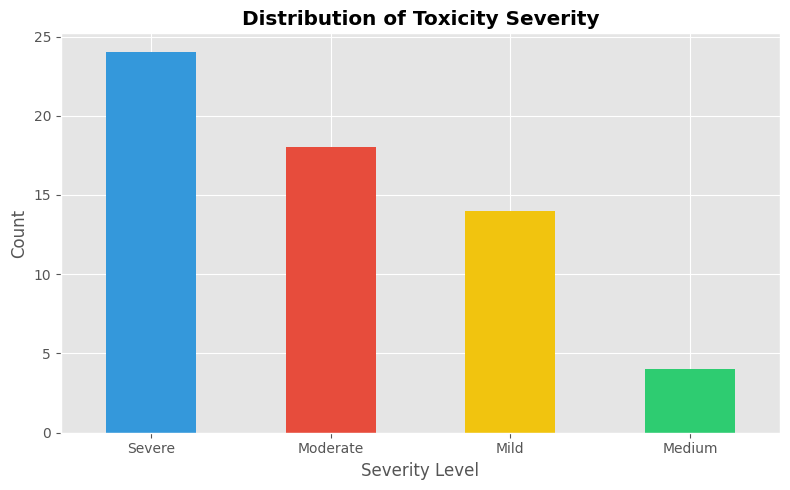

In [21]:
severity_counts = df['Severity'].value_counts()
print("Severity Count Distribution:")
print(severity_counts)

# Visualization: Bar Chart
plt.figure(figsize=(8, 5))
severity_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#f1c40f', '#2ecc71'])
plt.title('Distribution of Toxicity Severity', fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9. Groupby: Split-Apply-Combine (Slide 13)
The `.groupby()` method splits the data into groups based on some criteria, applies a function (like `.size()` to get counts), and combines the results.

**What this does:** Let's see the most common primary categories targeted in this text and graph the top 5.
**Expected Output:** You'll see a **Horizontal Bar Chart** visually ranking the top 5 targeted categories.

Primary Category counts:
Primary Category
Insult                  14
Offensive/Derogatory     8
Offensive                3
Insult / Humiliation     3
Humiliation / Insult     3
dtype: int64


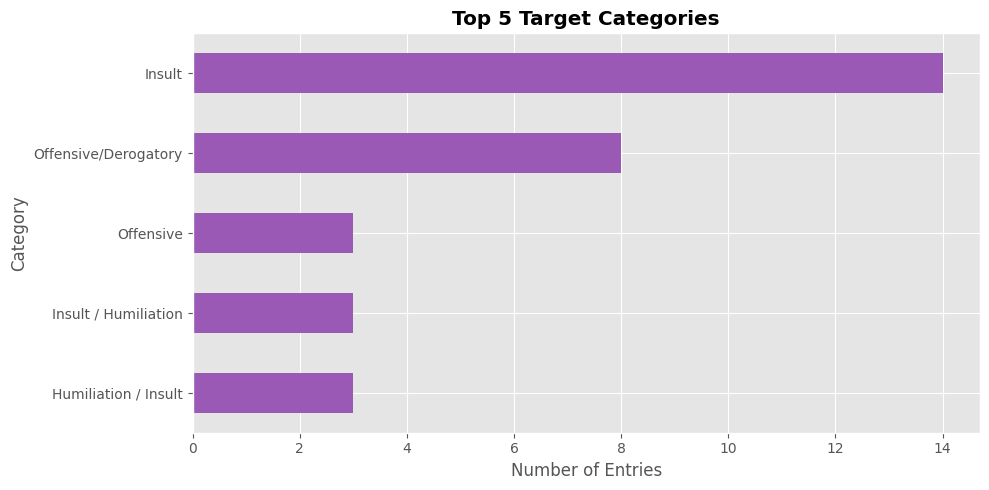

In [22]:
category_stats = df.groupby('Primary Category').size().sort_values(ascending=False)

print("Primary Category counts:")
print(category_stats.head())

# Visualization: Horizontal Bar Chart
plt.figure(figsize=(10, 5))
category_stats.head(5).plot(kind='barh', color='#9b59b6')
plt.title('Top 5 Target Categories', fontweight='bold')
plt.xlabel('Number of Entries')
plt.ylabel('Category')
plt.gca().invert_yaxis() # Invert to have the highest on top
plt.tight_layout()
plt.show()

### 10. Pivot Tables (Slide 17)
Pivot tables provide multidimensional summarization. 

**What this does:** Here, we cross-tabulate `Language` and `Severity` to understand how the severity spreads across different dialects.
**Expected Output:** A **Pivot Table** will appear showing a cross-grid of Language vs Severity, letting you see trends immediately.

In [23]:
pivot = df.pivot_table(
    values='Entry ID',
    index='Language',
    columns='Severity',
    aggfunc='count',
    fill_value=0,
    margins=True
)

display(pivot)

Severity,Medium,Mild,Moderate,Severe,All
Language,,,,,
English,3,0,6,8,17
English/Sheng,0,1,2,1,4
Kikuyu,0,0,1,1,2
Kisii,0,0,1,0,1
Kiswahili,0,3,1,0,4
Kiswahili/Sheng,0,3,2,2,7
Sheng,0,2,3,4,9
Sheng/Kiswahili,0,0,0,1,1
Sheng/Swahili,0,0,0,1,1


### 11. Automated Data Quality Report (Slide 18)
Before running any Machine Learning algorithm, you'll generally want to certify that the dataset follows specific ethical and validity rules.

**What this does:** Gives a custom summary panel verifying the integrity of the data (Total valid, Missing fields, Ethics checks, Invalid severities).
**Important Update:** Note that I changed the last bit of the original script! Instead of just printing `True` or `False` for whether it's ready for ML, I updated the logic to print `READY FOR AI/ML : YES or NO (Requires Cleaning)`. 

In [25]:
def dataset_quality_report(df):
    """Generate a human-readable quality report for the dataset."""
    total = len(df.dropna(subset=['Entry ID']))

    # 1. Completeness Check
    missing = df.isnull().sum().sum()

    # 2. Ethics check: Ensure all records are marked Anonymous
    # Using .str.strip() protects us against accidental spaces like ' Yes'
    ethics_ok = (df['Anon?'].str.strip() == 'Yes').sum()

    # 3. Validity: Ensure severity adheres precisely to allowed types
    VALID_SEV = ['Mild', 'Moderate', 'Severe', 'Medium']
    invalid_sev = (~df['Severity'].isin(VALID_SEV)).sum()

    # Final Verdict
    passed = (ethics_ok == total and invalid_sev == 0 and total >= 50)

    print("=" * 45)
    print("         DATASET QUALITY REPORT")
    print("=" * 45)
    print(f"Total valid entries : {total}")
    print(f"Total missing fields: {missing}")
    print(f"Ethics OK (Anon=Yes): {ethics_ok} / {total}")
    print(f"Invalid severities  : {invalid_sev}")
    print("-" * 45)
    
    if passed:
        print("READY FOR AI/ML     :  YES")
    else:
        print("READY FOR AI/ML     :  NO (Requires Cleaning)")
    print("=" * 45)

dataset_quality_report(df)

         DATASET QUALITY REPORT
Total valid entries : 60
Total missing fields: 2
Ethics OK (Anon=Yes): 60 / 60
Invalid severities  : 0
---------------------------------------------
READY FOR AI/ML     :  YES
